# HLA Typing Quality, Diversity, and Cohort Characterisation

This notebook produces publication-ready figures summarising the HLA typing
results for the PMLB neoantigen cohort. It covers:

1. **Typing quality** – success/failure rates, per-locus missingness, per-sample completeness
2. **Zygosity & diversity** – homo/heterozygosity, unique allele counts
3. **Allele frequency & cohort coverage** – top alleles, rank-frequency, cumulative coverage
4. **Cohort structure** – allele presence heatmap, PCA on binary allele features
5. **Sanity / QC checks** – allele count per locus, missing-allele bias

All figures are saved under `../results/hla/`.

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── output directory ──────────────────────────────────────────────────────────
OUT_DIR = '../results/hla'
os.makedirs(OUT_DIR, exist_ok=True)

# ── global aesthetics ─────────────────────────────────────────────────────────
PALETTE   = {'success': '#4C72B0', 'failure': '#DD8452'}
LOCUS_PAL = {'HLA-A': '#4C72B0', 'HLA-B': '#DD8452', 'HLA-C': '#55A868'}
ZYGOSITY_PAL = {'Heterozygous': '#4C72B0', 'Homozygous': '#C44E52'}

plt.rcParams.update({
    'figure.dpi':      150,
    'savefig.dpi':     300,
    'font.size':       11,
    'axes.titlesize':  13,
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family':     'sans-serif',
})

ALLELE_COLS = ['hla_a1','hla_a2','hla_b1','hla_b2','hla_c1','hla_c2']
LOCUS_MAP   = {'hla_a1':'HLA-A','hla_a2':'HLA-A',
               'hla_b1':'HLA-B','hla_b2':'HLA-B',
               'hla_c1':'HLA-C','hla_c2':'HLA-C'}

print('Environment ready.')

Environment ready.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING & CLEANING
# ─────────────────────────────────────────────────────────────────────────────

raw = pd.read_csv('../data/rna/hla_summary.csv', na_values=['NA', 'na', ''])
print(f'Loaded {len(raw)} rows')
print(raw.dtypes)
raw.head()

Loaded 232 rows
sample    object
status    object
reason    object
hla_a1    object
hla_a2    object
hla_b1    object
hla_b2    object
hla_c1    object
hla_c2    object
dtype: object


,sample,status,reason,hla_a1,hla_a2,hla_b1,hla_b2,hla_c1,hla_c2
0,BPTO0051.TPO,success,completed,A*01:01:01,A*01:01:01,B*57:01:01,B*57:01:01,C*06:02:01,C*06:02:01
1,BPTO0064.TXO,success,completed,A*02:01:01,A*02:01:01,NaN,NaN,C*07:04:01,C*07:04:01
2,BPTO0093.TPO,success,completed,A*29:01:01,A*11:01:01,B*35:08:01,B*51:01:01,C*04:01:01,C*15:05:02
3,BPTO0095.TPO,success,completed,A*11:01:01,A*24:02:01,B*40:02:01,B*40:02:01,C*02:02:02,C*14:03
4,BPTO0143.TXO,success,completed,A*25:01:01,A*25:01:01,B*18:01:01,B*18:01:01,C*12:03:01,C*12:03:01


In [4]:
def to_2field(allele):
    """Collapse an HLA allele string to 2-field resolution.
    e.g. 'A*01:01:01' -> 'A*01:01'   'B*57:01' -> 'B*57:01'
    Returns NaN for missing values.
    """
    if pd.isna(allele):
        return np.nan
    parts = str(allele).split(':')
    return ':'.join(parts[:2])

df = raw.copy()
for col in ALLELE_COLS:
    df[col] = df[col].apply(to_2field)

# Separate successful-typing samples for diversity analyses
df_ok = df[df['status'] == 'success'].copy()
print(f'Total samples : {len(df)}')
print(f'Success       : {(df.status=="success").sum()}')
print(f'Failure       : {(df.status=="failure").sum()}')
df.head()

Total samples : 232
Success       : 232
Failure       : 0


,sample,status,reason,hla_a1,hla_a2,hla_b1,hla_b2,hla_c1,hla_c2
0,BPTO0051.TPO,success,completed,A*01:01,A*01:01,B*57:01,B*57:01,C*06:02,C*06:02
1,BPTO0064.TXO,success,completed,A*02:01,A*02:01,NaN,NaN,C*07:04,C*07:04
2,BPTO0093.TPO,success,completed,A*29:01,A*11:01,B*35:08,B*51:01,C*04:01,C*15:05
3,BPTO0095.TPO,success,completed,A*11:01,A*24:02,B*40:02,B*40:02,C*02:02,C*14:03
4,BPTO0143.TXO,success,completed,A*25:01,A*25:01,B*18:01,B*18:01,C*12:03,C*12:03


---
## 1  HLA Typing Quality

       Both present  One missing  Both missing
Locus                                         
HLA-A          98.7          0.0           1.3
HLA-B          94.0          0.0           6.0
HLA-C          98.7          0.0           1.3


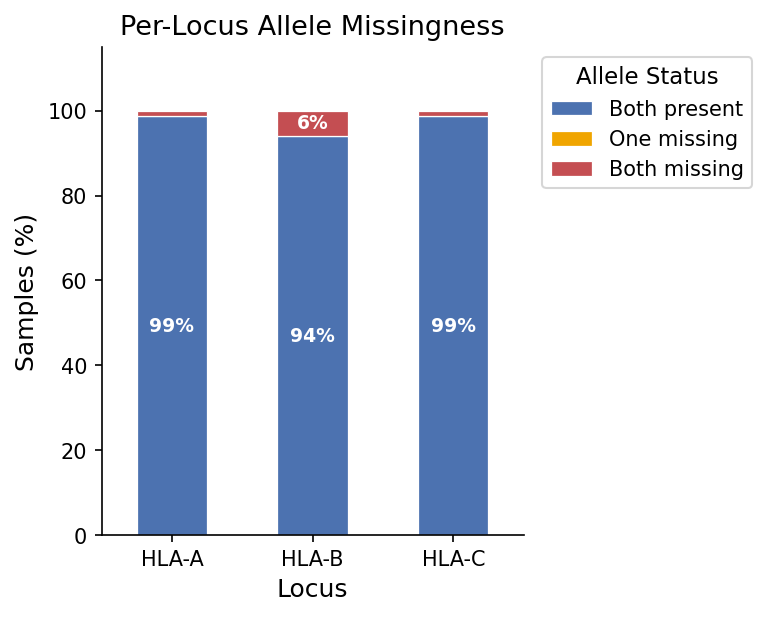

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 1.2  Missingness per locus
# ─────────────────────────────────────────────────────────────────────────────

def plot_locus_missingness(df_ok, out_dir):
    """Stacked bar: both present / one missing / both missing, per locus."""
    loci = [('HLA-A', 'hla_a1', 'hla_a2'),
            ('HLA-B', 'hla_b1', 'hla_b2'),
            ('HLA-C', 'hla_c1', 'hla_c2')]

    rows = []
    for locus, c1, c2 in loci:
        n1_ok = df_ok[c1].notna()
        n2_ok = df_ok[c2].notna()
        both_present = (n1_ok & n2_ok).sum()
        one_missing  = (n1_ok ^ n2_ok).sum()     # XOR
        both_missing = (~n1_ok & ~n2_ok).sum()
        total        = len(df_ok)
        rows.append({
            'Locus':         locus,
            'Both present':  both_present / total * 100,
            'One missing':   one_missing  / total * 100,
            'Both missing':  both_missing / total * 100,
        })

    miss_df = pd.DataFrame(rows).set_index('Locus')
    print(miss_df.round(1))

    fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
    miss_colors = ['#4C72B0', '#F0A500', '#C44E52']
    miss_df.plot(kind='bar', stacked=True, ax=ax, color=miss_colors,
                 edgecolor='white', linewidth=0.6, rot=0)

    ax.set_ylabel('Samples (%)')
    ax.set_title('Per-Locus Allele Missingness')
    ax.set_ylim(0, 115)
    # legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title='Allele Status', frameon=True)
    # ax.legend(loc='upper right', frameon=True, )
    ax.spines[['top', 'right']].set_visible(False)

    # annotate bars with actual %
    bottoms = np.zeros(3)
    for col, color in zip(miss_df.columns, miss_colors):
        vals = miss_df[col].values
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v > 3:
                ax.text(i, b + v / 2, f'{v:.0f}%',
                        ha='center', va='center', fontsize=9,
                        color='white', fontweight='bold')
        bottoms += vals

    fig.savefig(os.path.join(out_dir, 'locus_missingness.png'), bbox_inches='tight')
    plt.show()

plot_locus_missingness(df_ok, OUT_DIR)

## 2  Zygosity and Diversity

   Locus      Zygosity  Proportion (%)
0  HLA-A  Heterozygous       58.951965
1  HLA-A    Homozygous       41.048035
2  HLA-B  Heterozygous       61.467890
3  HLA-B    Homozygous       38.532110
4  HLA-C  Heterozygous       61.135371
5  HLA-C    Homozygous       38.864629


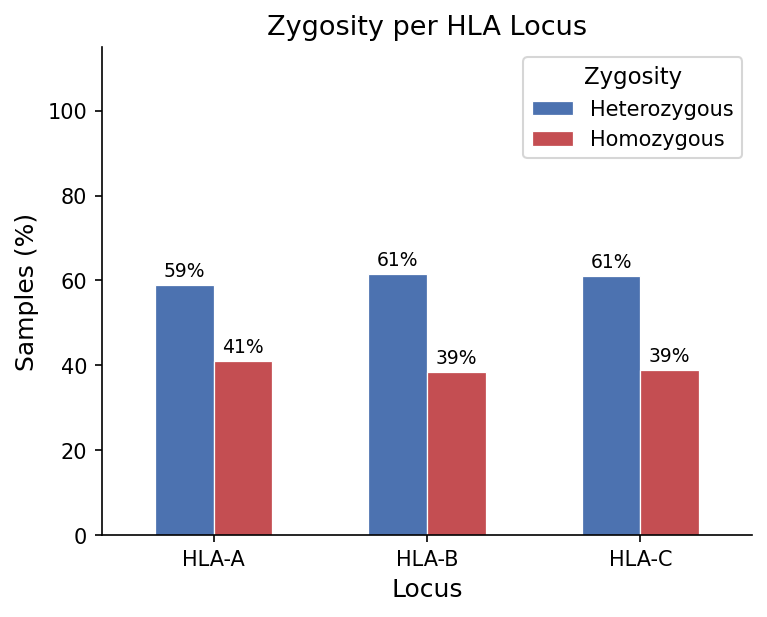

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.1  Homozygosity vs heterozygosity per locus
# ─────────────────────────────────────────────────────────────────────────────

def classify_zygosity(row, c1, c2):
    """Return 'Homozygous', 'Heterozygous', or NaN if either allele missing."""
    a1, a2 = row[c1], row[c2]
    if pd.isna(a1) or pd.isna(a2):
        return np.nan
    return 'Homozygous' if a1 == a2 else 'Heterozygous'

def plot_zygosity(df_ok, out_dir):
    loci = [('HLA-A', 'hla_a1', 'hla_a2'),
            ('HLA-B', 'hla_b1', 'hla_b2'),
            ('HLA-C', 'hla_c1', 'hla_c2')]

    rows = []
    for locus, c1, c2 in loci:
        zyg = df_ok.apply(classify_zygosity, axis=1, c1=c1, c2=c2).dropna()
        vc  = zyg.value_counts(normalize=True) * 100
        for cat in ['Heterozygous', 'Homozygous']:
            rows.append({'Locus': locus, 'Zygosity': cat,
                         'Proportion (%)': vc.get(cat, 0)})

    zyg_df = pd.DataFrame(rows)
    print(zyg_df)

    fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
    pivot = zyg_df.pivot(index='Locus', columns='Zygosity',
                         values='Proportion (%)')[['Heterozygous', 'Homozygous']]
    pivot.plot(kind='bar', ax=ax,
               color=[ZYGOSITY_PAL['Heterozygous'], ZYGOSITY_PAL['Homozygous']],
               edgecolor='white', linewidth=0.6, rot=0, width=0.55)

    ax.set_ylabel('Samples (%)')
    ax.set_title('Zygosity per HLA Locus')
    ax.set_ylim(0, 115)
    ax.legend(title='Zygosity', frameon=True)
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate bars
    for patch in ax.patches:
        h = patch.get_height()
        if h > 3:
            ax.text(patch.get_x() + patch.get_width() / 2,
                    h + 1, f'{h:.0f}%',
                    ha='center', va='bottom', fontsize=9)

    fig.savefig(os.path.join(out_dir, 'zygosity.png'), bbox_inches='tight')
    plt.show()

plot_zygosity(df_ok, OUT_DIR)

---
## 3  Allele Frequency and Cohort Coverage

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper: build long-format allele table
# ─────────────────────────────────────────────────────────────────────────────

def build_allele_long(df_ok):
    """Melt to one allele per row; add locus column."""
    long = df_ok.melt(id_vars='sample', value_vars=ALLELE_COLS,
                      var_name='slot', value_name='allele')
    long['locus'] = long['slot'].map(LOCUS_MAP)
    long = long.dropna(subset=['allele'])
    return long

allele_long = build_allele_long(df_ok)
print(allele_long.shape)
allele_long.head()

(1352, 4)


,sample,slot,allele,locus
0,BPTO0051.TPO,hla_a1,A*01:01,HLA-A
1,BPTO0064.TXO,hla_a1,A*02:01,HLA-A
2,BPTO0093.TPO,hla_a1,A*29:01,HLA-A
3,BPTO0095.TPO,hla_a1,A*11:01,HLA-A
4,BPTO0143.TXO,hla_a1,A*25:01,HLA-A


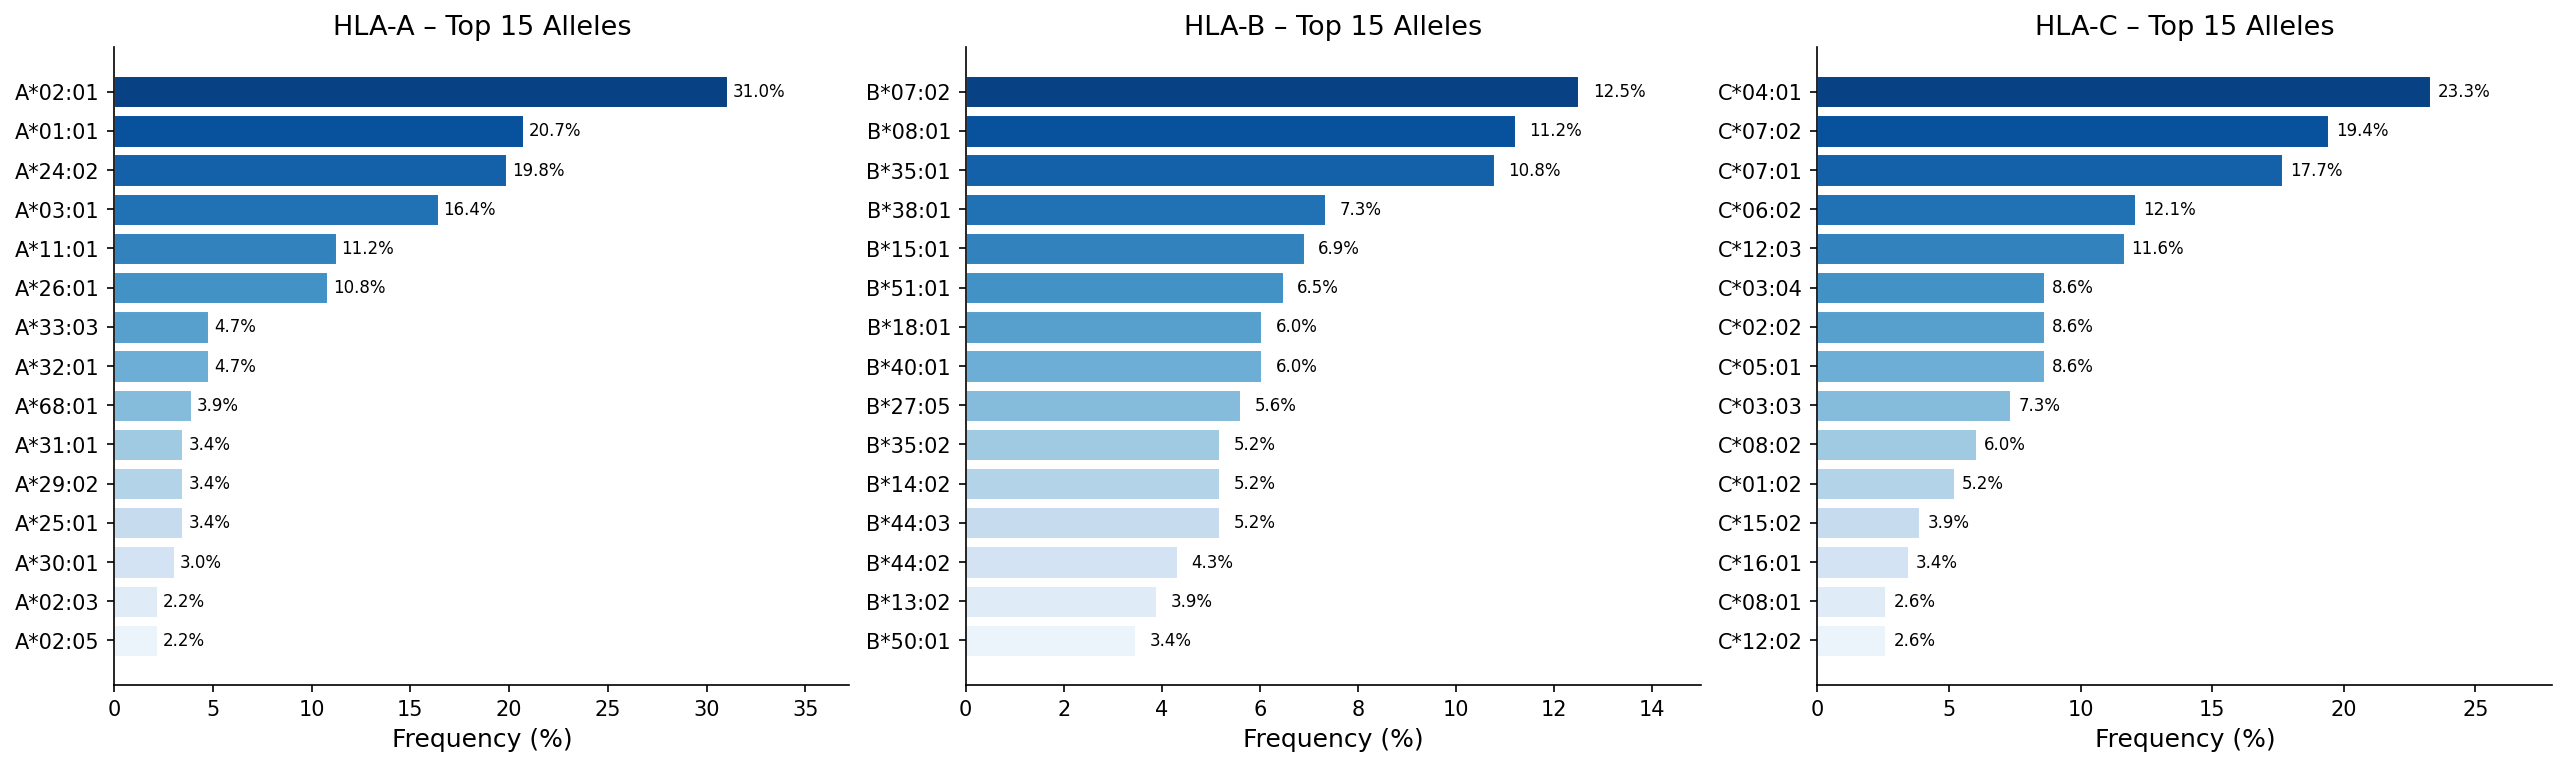

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.1  Top-N allele frequency per locus
# ─────────────────────────────────────────────────────────────────────────────

def plot_top_alleles(allele_long, df_ok, out_dir, top_n=15):
    """Bar plot of the most frequent alleles for each locus."""
    n_samples = len(df_ok)
    loci = ['HLA-A', 'HLA-B', 'HLA-C']

    fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)

    for ax, locus in zip(axes, loci):
        sub = allele_long[allele_long['locus'] == locus]
        # Allele frequency = # samples carrying the allele (in either slot)
        freq = (sub.groupby('allele')['sample']
                   .nunique()
                   .sort_values(ascending=False)
                   .head(top_n))
        pct = freq / n_samples * 100

        colors = sns.color_palette("Blues_r", len(pct))
        bars = ax.barh(pct.index[::-1], pct.values[::-1],
                       color=colors[::-1], edgecolor='white', linewidth=0.5)
        ax.set_xlabel('Frequency (%)')
        ax.set_title(f'{locus} – Top {top_n} Alleles')
        ax.spines[['top', 'right']].set_visible(False)
        for bar, v in zip(bars, pct.values[::-1]):
            ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
                    f'{v:.1f}%', va='center', fontsize=8)
        ax.set_xlim(0, pct.max() * 1.2)

    fig.savefig(os.path.join(out_dir, 'top_allele_frequencies.png'), bbox_inches='tight')
    plt.show()

plot_top_alleles(allele_long, df_ok, OUT_DIR)

---
## 5  Sanity / QC Checks

✓ All samples have ≤2 alleles per locus.


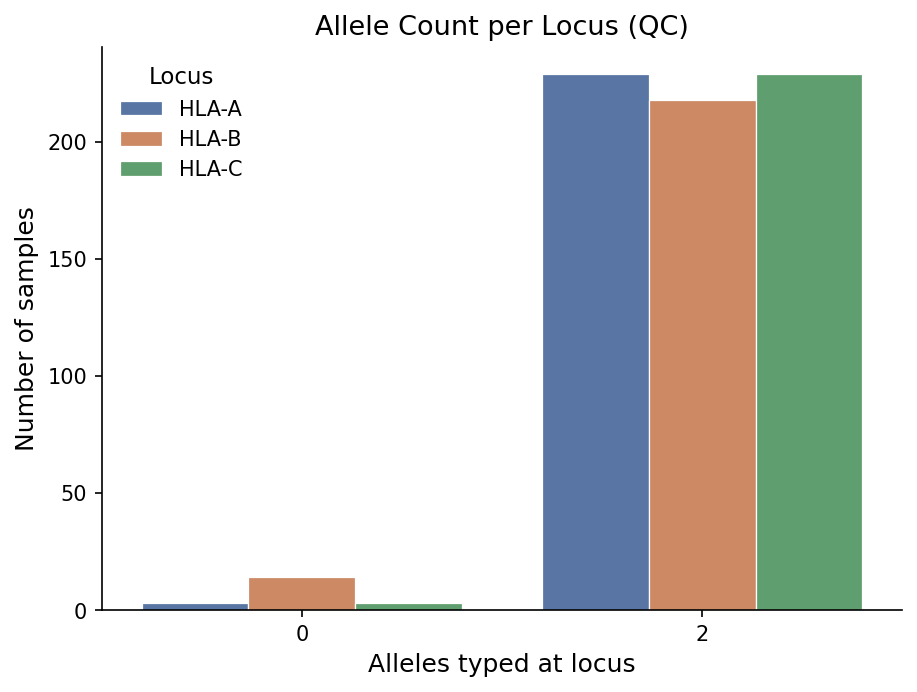

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.1  Allele count per locus per sample
# ─────────────────────────────────────────────────────────────────────────────

def plot_allele_count_qc(df_ok, out_dir):
    """Confirm each sample has ≤2 alleles per locus; plot count distribution."""
    loci_pairs = [('HLA-A', 'hla_a1', 'hla_a2'),
                  ('HLA-B', 'hla_b1', 'hla_b2'),
                  ('HLA-C', 'hla_c1', 'hla_c2')]

    rows = []
    violations = []
    for locus, c1, c2 in loci_pairs:
        for _, row in df_ok.iterrows():
            alleles = [a for a in [row[c1], row[c2]] if pd.notna(a)]
            cnt = len(alleles)
            rows.append({'Locus': locus, 'Allele count': cnt})
            if cnt > 2:
                violations.append((row['sample'], locus, cnt))

    if violations:
        print('⚠ Samples with > 2 alleles per locus:')
        for v in violations:
            print(f'  {v}')
    else:
        print('✓ All samples have ≤2 alleles per locus.')

    count_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
    sns.countplot(data=count_df, x='Allele count', hue='Locus',
                  palette=LOCUS_PAL, ax=ax,
                  edgecolor='white', linewidth=0.6)
    ax.set_xlabel('Alleles typed at locus')
    ax.set_ylabel('Number of samples')
    ax.set_title('Allele Count per Locus (QC)')
    ax.legend(title='Locus', frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

    fig.savefig(os.path.join(out_dir, 'allele_count_qc.png'), bbox_inches='tight')
    plt.show()

plot_allele_count_qc(df_ok, OUT_DIR)

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Summary statistics table
# ─────────────────────────────────────────────────────────────────────────────

n_total   = len(df)
n_success = (df['status'] == 'success').sum()
n_fail    = (df['status'] == 'failure').sum()

all_alleles = allele_long['allele'].nunique()
a_alleles   = allele_long[allele_long['locus']=='HLA-A']['allele'].nunique()
b_alleles   = allele_long[allele_long['locus']=='HLA-B']['allele'].nunique()
c_alleles   = allele_long[allele_long['locus']=='HLA-C']['allele'].nunique()

summary = pd.DataFrame({
    'Metric': [
        'Total samples',
        'Typing success',
        'Typing failure',
        'Unique alleles (all loci)',
        'Unique HLA-A alleles',
        'Unique HLA-B alleles',
        'Unique HLA-C alleles',
    ],
    'Value': [
        n_total,
        f'{n_success} ({n_success/n_total*100:.1f}%)',
        f'{n_fail} ({n_fail/n_total*100:.1f}%)',
        all_alleles, a_alleles, b_alleles, c_alleles,
    ]
})

print('\n=== Cohort Summary ===')
print(summary.to_string(index=False))
summary.to_csv(os.path.join(OUT_DIR, 'cohort_summary.csv'), index=False)
print('\nAll outputs saved to', OUT_DIR)


=== Cohort Summary ===
                   Metric        Value
            Total samples          232
           Typing success 232 (100.0%)
           Typing failure     0 (0.0%)
Unique alleles (all loci)          125
     Unique HLA-A alleles           32
     Unique HLA-B alleles           62
     Unique HLA-C alleles           31

All outputs saved to ../results/hla


---
## 6  HLA Class I Oncoplot

Oncoplot-style visualisation: rows = alleles (A/B/C), columns = samples sorted by allele count.
Cell colour encodes which allele slot carried the allele (allele 1 = light, allele 2 = dark),
making homozygous samples immediately visible. Right panel shows per-allele sample frequency (%).

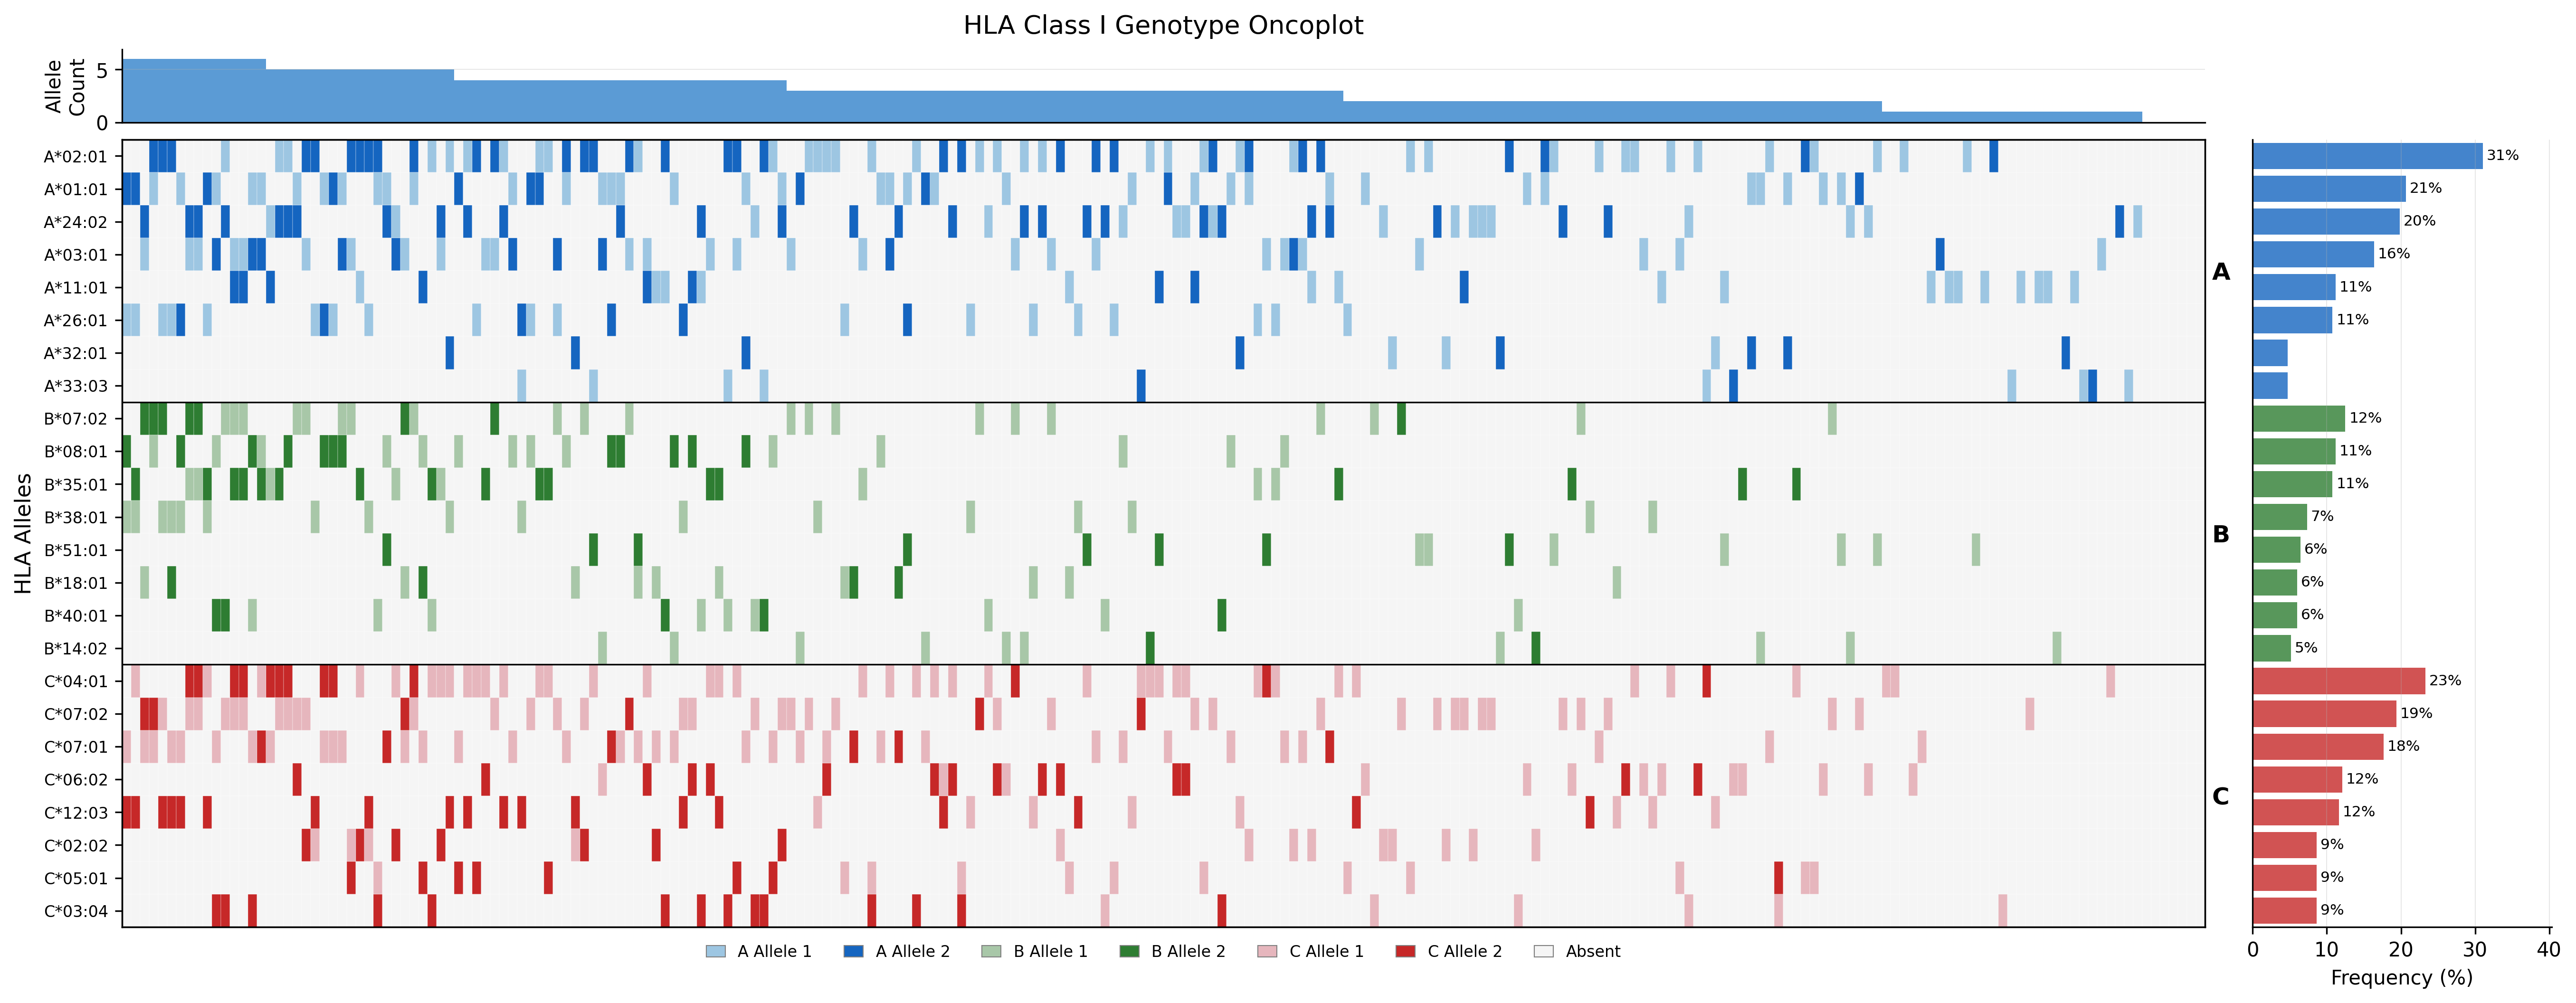

In [11]:
import re
from collections import Counter
import matplotlib.patches as mpatches

# ── colour scheme: light/dark pairs per locus ────────────────────────────────
ONCO_COLORS = {
    'absent':  '#F5F5F5',
    'hla_a1':  "#9DC6E2",
    'hla_a2':  '#1565C0',
    'hla_b1':  "#A8C7A8",
    'hla_b2':  '#2E7D32',
    'hla_c1':  "#E6B6BD",
    'hla_c2':  '#C62828',
}
LOCUS_DARK  = {'A': '#1565C0', 'B': '#2E7D32', 'C': '#C62828'}
LOCUS_PAIRS = [('A', 'hla_a1', 'hla_a2'),
               ('B', 'hla_b1', 'hla_b2'),
               ('C', 'hla_c1', 'hla_c2')]


def _to2(allele):
    if pd.isna(allele) or str(allele).strip() in ('', '-', 'NA'):
        return None
    m = re.search(r'\*(\d{2}:\d{2})', str(allele))
    if m:
        return f"{allele.split('*')[0]}*{m.group(1)}"
    return str(allele)


def prepare_classI_oncoplot(df_ok, alleles_per_locus=8):
    locus_groups = {}
    selected     = []
    for locus, c1, c2 in LOCUS_PAIRS:
        raw = [_to2(v) for col in (c1, c2) for v in df_ok[col]]
        raw = [a for a in raw if a]
        top = [a for a, _ in Counter(raw).most_common(alleles_per_locus)]
        locus_groups[locus] = top
        selected += top

    records = []
    for _, row in df_ok.iterrows():
        d = {'sample': row['sample']}
        for allele in selected:
            slots = [col for _, c1, c2 in LOCUS_PAIRS
                     for col in (c1, c2) if _to2(row[col]) == allele]
            d[allele] = slots[0] if slots else 'absent'
        records.append(d)

    presence_df = pd.DataFrame(records)
    n = len(df_ok)
    frequencies = {a: (presence_df[a] != 'absent').sum() / n * 100 for a in selected}
    sample_counts = [(presence_df.iloc[i][selected] != 'absent').sum() for i in range(n)]
    return presence_df, frequencies, sample_counts, locus_groups


def create_classI_oncoplot(presence_df, frequencies, sample_counts, locus_groups,
                           out_dir, alleles_per_locus=8, figsize=(22, 8)):
    ordered_alleles = []
    locus_spans     = {}
    pos = 0
    for locus, _, _ in LOCUS_PAIRS:
        top = sorted(locus_groups[locus], key=lambda a: frequencies.get(a, 0), reverse=True)
        ordered_alleles += top
        locus_spans[locus] = (pos, pos + len(top))
        pos += len(top)
    n_alleles = len(ordered_alleles)
    n_samples = len(presence_df)
    sample_order = np.argsort(sample_counts)[::-1]

    fig = plt.figure(figsize=figsize, dpi=300)
    gs  = fig.add_gridspec(2, 2,
                           height_ratios=[1, n_alleles * 0.45],
                           width_ratios=[n_samples * 0.09, 3],
                           hspace=0.04, wspace=0.04)
    ax_top   = fig.add_subplot(gs[0, 0])
    ax_main  = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1])
    fig.add_subplot(gs[0, 1]).set_visible(False)

    # top bar
    ax_top.bar(range(n_samples), [sample_counts[i] for i in sample_order],
               color='#5B9BD5', width=1.0, linewidth=0)
    ax_top.set_xlim(-0.5, n_samples - 0.5)
    ax_top.set_ylim(0, max(sample_counts) * 1.15)
    ax_top.set_ylabel('Allele\nCount', fontsize=10)
    ax_top.set_title('HLA Class I Genotype Oncoplot', fontsize=13, pad=8)
    ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_top.spines[['top', 'right']].set_visible(False)
    ax_top.grid(axis='y', alpha=0.3, linewidth=0.5)

    # main heatmap
    for i, allele in enumerate(ordered_alleles):
        y = n_alleles - i - 1
        for j, sidx in enumerate(sample_order):
            slot  = presence_df.iloc[sidx][allele]
            color = ONCO_COLORS.get(slot, ONCO_COLORS['absent'])
            ax_main.add_patch(
                mpatches.Rectangle((j, y), 1, 1, linewidth=0.1,
                                   edgecolor='white', facecolor=color))

    ax_rlabel = ax_main.twinx()
    locus_tick_pos, locus_tick_lbl = [], []
    current_y = n_alleles
    for k, (locus, _, _) in enumerate(LOCUS_PAIRS):
        start, end = locus_spans[locus]
        h = end - start
        if k > 0:
            ax_main.axhline(current_y, color='black', linewidth=0.8)
        locus_tick_pos.append(current_y - h / 2)
        locus_tick_lbl.append(locus)
        current_y -= h

    ax_main.set_xlim(0, n_samples)
    ax_main.set_ylim(0, n_alleles)
    ax_main.set_yticks([i + 0.5 for i in range(n_alleles)])
    ax_main.set_yticklabels(list(reversed(ordered_alleles)), fontsize=8)
    ax_main.set_ylabel('HLA Alleles', fontsize=11)
    ax_main.tick_params(axis='x', bottom=False, labelbottom=False)

    ax_rlabel.set_ylim(0, n_alleles)
    ax_rlabel.set_yticks(locus_tick_pos)
    ax_rlabel.set_yticklabels(locus_tick_lbl, fontsize=12, fontweight='bold')
    ax_rlabel.tick_params(axis='y', length=0)

    # right frequency bar
    freq_vals  = [frequencies.get(a, 0) for a in reversed(ordered_alleles)]
    bar_colors = [LOCUS_DARK[a.split('*')[0]] for a in reversed(ordered_alleles)]
    bars = ax_right.barh(range(n_alleles), freq_vals,
                         color=bar_colors, alpha=0.8, height=0.8)
    for bar, fv in zip(bars, freq_vals):
        if fv >= 5:
            ax_right.text(bar.get_width() + 0.5,
                          bar.get_y() + bar.get_height() / 2,
                          f'{fv:.0f}%', va='center', fontsize=7.5)
    ax_right.set_ylim(-0.5, n_alleles - 0.5)
    ax_right.set_xlim(0, max(freq_vals) * 1.3 if freq_vals else 10)
    ax_right.set_xlabel('Frequency (%)', fontsize=10)
    ax_right.tick_params(axis='y', left=False, labelleft=False)
    ax_right.spines[['top', 'right']].set_visible(False)
    ax_right.grid(axis='x', alpha=0.3, linewidth=0.5)

    # legend
    legend_els = []
    for locus, c1, c2 in LOCUS_PAIRS:
        legend_els += [
            mpatches.Patch(facecolor=ONCO_COLORS[c1], edgecolor='grey',
                           linewidth=0.5, label=f'{locus} Allele 1'),
            mpatches.Patch(facecolor=ONCO_COLORS[c2], edgecolor='grey',
                           linewidth=0.5, label=f'{locus} Allele 2'),
        ]
    legend_els.append(mpatches.Patch(facecolor=ONCO_COLORS['absent'],
                                      edgecolor='grey', linewidth=0.5, label='Absent'))
    ax_main.legend(handles=legend_els, ncol=7, fontsize=8,
                   loc='lower center', bbox_to_anchor=(0.5, -0.06),
                   frameon=False, handlelength=1.2)

    plt.savefig(os.path.join(out_dir, 'hla_oncoplot.png'),
                bbox_inches='tight', facecolor='white')
    plt.show()


# run
presence_df_onco, freqs_onco, scounts_onco, lgroups_onco = \
    prepare_classI_oncoplot(df_ok, alleles_per_locus=8)

create_classI_oncoplot(presence_df_onco, freqs_onco, scounts_onco, lgroups_onco,
                       out_dir=OUT_DIR, figsize=(22, 8))


## Nhu-An/Quan HLA Request

In [18]:
# metadata table
meta = pd.read_csv('/Users/vivianschu/repos/pmlb-neoantigens/data/rna/metadata.csv')
# print(meta.dtypes)
# meta.head()

# merge metadata table with hla table on 'sample' column; in metadata table is named 'PMLB_organoidID'
merged = pd.merge(df_ok, meta, left_on='sample', right_on='PMLB_organoidID', how='left')
# print(merged.dtypes)
# merged.head()

# filter for only lung cancer samples by oncotree code
lung_codes = ['LUAD', 'LUNE', 'LUSC', 'SCLC', 'LUPC', 'CSCLC', 'NSCLC']
merged_lung = merged[merged['oncotree_code'].isin(lung_codes)].copy()
print(f'Lung cancer samples: {len(merged_lung)}')
merged_lung.head()

# export as table
merged_lung.to_csv(os.path.join(OUT_DIR, 'lung_samples_metadata.csv'), index=False)

Lung cancer samples: 58
